# analysis

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os
sys.path.append(f'{os.getcwd()}/irc_gym')

In [3]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from auditoryforage.AF_env import AuditoryForaging as AF
from auditoryforage.AF_env import AuditoryForagingReward as AFR
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2
from stable_baselines3 import PPO
from irc_gym.irc.model import FuncBeliefModel
from multiprocessing import Pool
import multiprocessing as mp
from matplotlib import pyplot as plt
import numpy as np
from collections import defaultdict
import seaborn as sns
import multiprocessing
from ult import *

# settings

In [4]:
food_reward_list = food_reward_list = np.linspace(10, 9999, 5)
env_param = [-10, 1500, 0.087213, .25, -50, -10, 0]

task = AFR2(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5], 'time_in_game_reward': env_param[6]}})
num_epochs = 1
task.food_reward_list = food_reward_list

taskbelief = FuncBeliefModel(env=task, rng=1)

agent=PPO.load('ycstore/seed_0_date_16_periodic_e3_e5', device='cpu')
no_episodes = 22222

# collect data

In [24]:
# run mp job
def eval_wrapper(a):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=agent,num_steps=100000)
    food_reward_idx,hit_count,miss_count,false_alarm_count,noise_time_before_lick,signal_time_before_lick,total_noise_time,total_signal_time,total_reward,attention_time_points_across_episodes,episode_length_across_episodes,hit_reaction_time_across_episodes,fa_reaction_time_across_episodes = process_one_episode(
        episode, task)
    return (food_reward_idx,
            hit_count,
            miss_count,
            false_alarm_count,
            noise_time_before_lick,
            signal_time_before_lick,
            total_noise_time,
            total_signal_time,
            total_reward,
            attention_time_points_across_episodes,
            episode_length_across_episodes,
            hit_reaction_time_across_episodes,
            fa_reaction_time_across_episodes
            )


with multiprocessing.Pool(processes=27) as pool:
    results = pool.map(eval_wrapper, range(no_episodes))


KeyboardInterrupt: 

In [98]:

# process the mp results
hit_count_list = [[0] for _ in range(len(food_reward_list))]
miss_count_list = [[0] for _ in range(len(food_reward_list))]
false_alarm_list = [[0] for _ in range(len(food_reward_list))]

noise_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
signal_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
total_noise_time_list = [[0] for _ in range(len(food_reward_list))]
total_signal_time_list = [[0] for _ in range(len(food_reward_list))]

# dist naming space: list of list of num. big list of each reward cond. small list of each trial's summary stats, which is a single number.
total_reward_dist= [[] for _ in range(len(food_reward_list))]
rt_hit_dist=[[] for _ in range(len(food_reward_list))]
rt_fa_dist=[[] for _ in range(len(food_reward_list))]
total_att_time_dist = [[] for _ in range(len(food_reward_list))]
for res in results:
    (food_reward_idx,
     hit_count,
     miss_count,
     false_alarm_count,

     noise_time_before_lick,
     signal_time_before_lick,
     total_noise_time,
     total_signal_time,

     total_reward,

     attention_time_points_across_episodes,
     episode_length_across_episodes,
     hit_reaction_time_across_episodes,
     fa_reaction_time_across_episodes
     ) = res

    hit_count_list[food_reward_idx][0] += (hit_count)
    miss_count_list[food_reward_idx][0] += (miss_count)
    false_alarm_list[food_reward_idx][0] += (false_alarm_count)

    noise_time_before_lick_list[food_reward_idx][0] += (noise_time_before_lick)
    signal_time_before_lick_list[food_reward_idx][0] += (
        signal_time_before_lick)
    total_noise_time_list[food_reward_idx][0] += (total_noise_time)
    total_signal_time_list[food_reward_idx][0] += (total_signal_time)

    total_reward_dist[food_reward_idx].append(total_reward)
    rt_hit_dist[food_reward_idx].append(signal_time_before_lick)
    rt_fa_dist[food_reward_idx].append(noise_time_before_lick)
    total_att_time_dist[food_reward_idx].append(len(attention_time_points_across_episodes[0]))

# plots

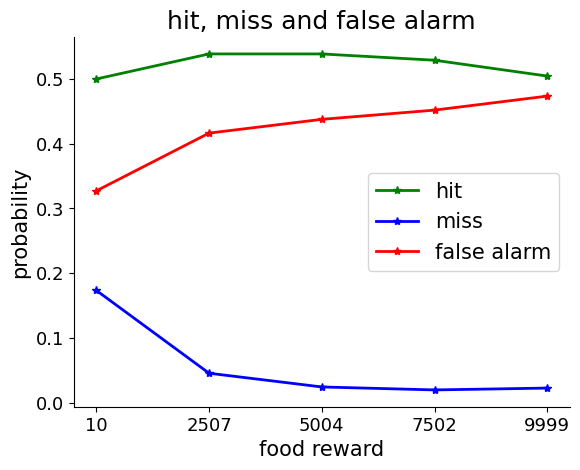

In [13]:
# figure 1
#n classic 3 color curve.
plot_hit_miss_FA(food_reward_list, hit_count_list, miss_count_list, false_alarm_list, 'hit, miss and false alarm')

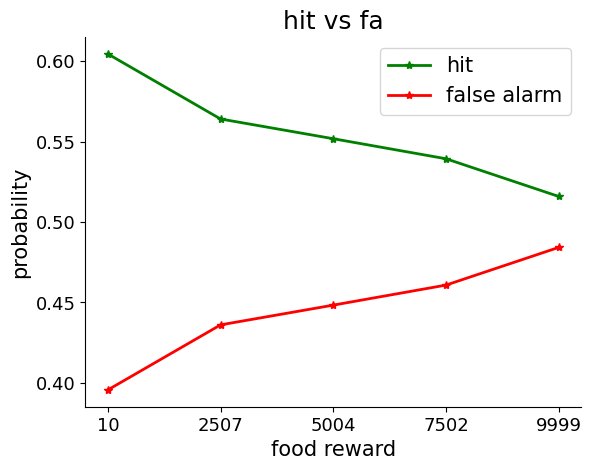

In [19]:
# figure 2
#  hit and fa curve.
plot_hit_fa(food_reward_list, hit_count_list, false_alarm_list, 'hit vs fa')
# extra, hit and miss
# plot_hit_miss(food_reward_list, hit_count_list, miss_count_list, 'hit vs miss')

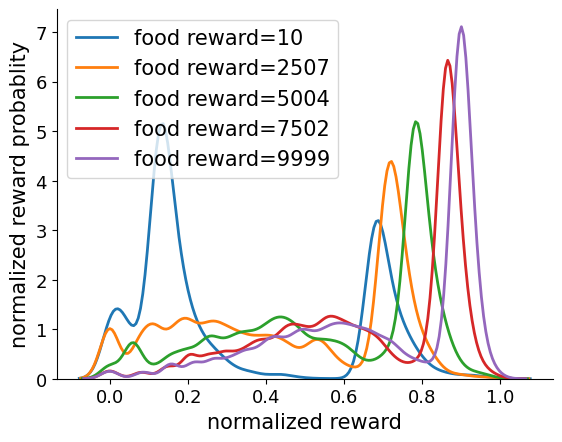

In [109]:
# figure 3, food reward distribution
for food_reward_idx, v in enumerate(total_reward_dist):
    v = (v - min(v)) / (max(v) - min(v))
    v = 1-v
    sns.kdeplot(v, fill=False, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', bw_adjust=0.5,)
plt.ylabel('normalized reward probablity')
plt.xlabel('normalized reward')
plt.legend()
plt.show()


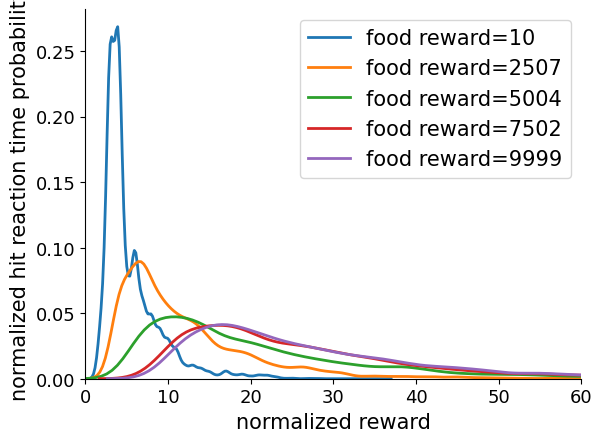

In [108]:
# figure 4
# total attention time in one trial distubition, similar to the reward distribution during training

for food_reward_idx, v in enumerate(total_att_time_dist):
    v = np.array(v)
    # ignore the 0 reaction time in the plots
    sns.kdeplot(v, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', clip=(0, np.max(v)), bw_adjust=0.7)
plt.xlim(0,60)
plt.ylabel('normalized total attention time probability')
plt.xlabel('normalized reward')
plt.legend()
plt.show()



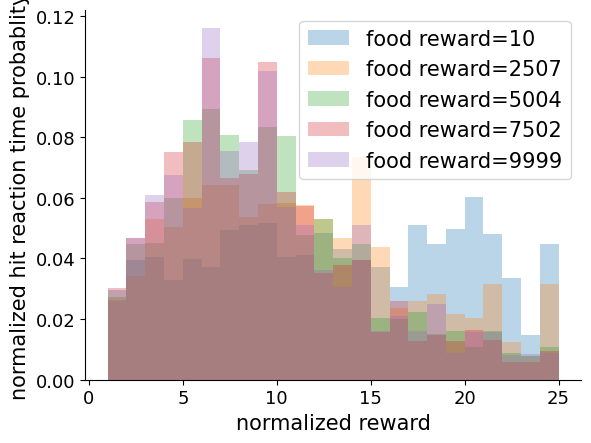

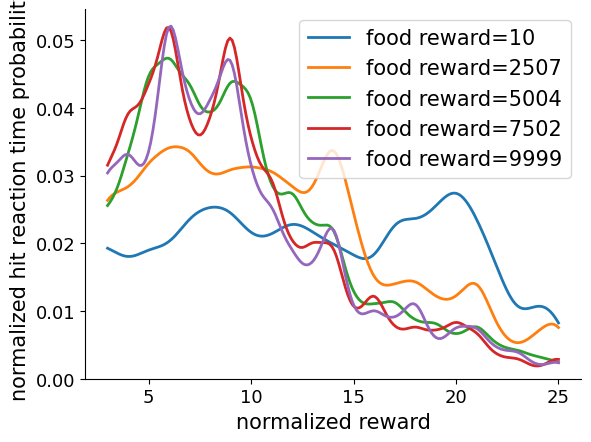

In [111]:

# figure 5
# reaction time distubition, similar to the reward distribution during training
for food_reward_idx, v in enumerate(rt_hit_dist):
    v=np.array(v)
    # ignore the 0 reaction time in the plots
    _=plt.hist(v, bins=np.arange(1, np.max(v) + 1), density=True, alpha=0.3, label=f'food reward={food_reward_list[food_reward_idx]:.0f}',)
plt.ylabel('normalized hit reaction time probablity')
plt.xlabel('normalized reward')
plt.legend()
plt.show()

# alt
for food_reward_idx, v in enumerate(rt_hit_dist):
    v = np.array(v)
    # ignore the 0 reaction time in the plots
    sns.kdeplot(v, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', clip=(3, np.max(v)), bw_adjust=0.5)

plt.ylabel('normalized hit reaction time probability')
plt.xlabel('normalized reward')
plt.legend()
plt.show()


## falase alarm reaction time
# for food_reward_idx, v in enumerate(rt_fa_dist):
#     v=np.array(v)
#     _=plt.hist(v, bins=np.arange(1, np.max(v) + 1), density=True, alpha=0.3, label=f'food reward={food_reward_list[food_reward_idx]:.0f}',)
# plt.ylabel('normalized fa reaction time probablity')
# plt.xlabel('normalized reward')
# plt.legend()
# plt.show()


# # alt
# for food_reward_idx, v in enumerate(rt_fa_dist):
#     v = np.array(v)
#     # ignore the 0 reaction time in the plots
#     sns.kdeplot(v, label=f'food reward={food_reward_list[food_reward_idx]:.0f}', clip=(3, np.max(v)), bw_adjust=0.5)

# plt.ylabel('normalized hit reaction time probability')
# plt.xlabel('normalized reward')
# plt.legend()
# plt.show()




# working space

In [112]:
# added may1st, figure 6
for food_reward_idx in all_reward_res.keys():
    
    attention_prob_list,lick_prob_list,lick_time_list,att_time_list, trial_len=all_reward_res[food_reward_idx]

    data=att_time_list        
    padded=pad_zero_attention(data)
    trial_count_i=count_less_equal_index(trial_len)
    plt.figure()
    # plt.plot(np.sum(padded, axis=0)*np.cumsum(trial_count_i))
    # plt.plot(np.sum(padded, axis=0)/(trial_count_i))
    plt.plot(np.sum(padded, axis=0)/(smooth_list(trial_count_i, window_size=5)))
    plt.xlabel('time in trial')
    plt.ylabel('normalized count')
    plt.title(f'attention time, normlized by trial length\nfood_reward={food_reward_list[food_reward_idx]:.0f}')
    plt.show()

NameError: name 'all_reward_res' is not defined